In [1]:
import pandas as pd

file_path = "../data/cloud_anomaly.csv"

df_sample = pd.read_csv(file_path, nrows=1000)

df_sample.head()

,timestamp,service_name,log_level,response_time_ms,cpu_usage_percent,memory_usage_mb,region,anomaly_type
0,2025-01-01 00:00:00,PaymentGateway,CRITICAL,2684.28,30.95,1045.10,eu-west-1,Normal
1,2025-01-01 00:05:00,UserAPI,INFO,1576.21,91.53,4372.13,us-east-1,Normal
2,2025-01-01 00:10:00,UserAPI,WARNING,433.45,61.48,13350.82,us-east-1,Normal
3,2025-01-01 00:15:00,UserAPI,WARNING,2052.72,40.36,12110.04,ap-south-1,Normal
4,2025-01-01 00:20:00,NotificationService,INFO,1167.97,29.52,3102.82,ap-south-1,Normal


In [10]:
df = pd.read_csv(file_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))


Rows: 200
Columns: 8


In [2]:
df_sample.shape

(200, 8)

In [3]:
df_sample.columns.tolist()


['timestamp',
 'service_name',
 'log_level',
 'response_time_ms',
 'cpu_usage_percent',
 'memory_usage_mb',
 'region',
 'anomaly_type']

In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          200 non-null    object 
 1   service_name       200 non-null    object 
 2   log_level          200 non-null    object 
 3   response_time_ms   200 non-null    float64
 4   cpu_usage_percent  200 non-null    float64
 5   memory_usage_mb    200 non-null    float64
 6   region             200 non-null    object 
 7   anomaly_type       200 non-null    object 
dtypes: float64(3), object(5)
memory usage: 12.6+ KB


In [5]:
df_sample["anomaly_type"].value_counts()


anomaly_type
Normal          131
DiskFailure      18
NetworkDrop      14
CPUOverload      13
MemoryLeak       12
LatencySpike     12
Name: count, dtype: int64

In [6]:
df_sample["anomaly_type"].value_counts(normalize=True) * 100

anomaly_type
Normal          65.5
DiskFailure      9.0
NetworkDrop      7.0
CPUOverload      6.5
MemoryLeak       6.0
LatencySpike     6.0
Name: proportion, dtype: float64

In [7]:
for col in ["service_name", "log_level", "region", "anomaly_type"]:
    print(f"\n--- {col} ---")
    print(df_sample[col].value_counts())


--- service_name ---
service_name
UserAPI                43
AuthService            43
PaymentGateway         41
SearchEngine           40
NotificationService    33
Name: count, dtype: int64

--- log_level ---
log_level
WARNING     62
INFO        56
CRITICAL    54
ERROR       28
Name: count, dtype: int64

--- region ---
region
ap-south-1    82
us-east-1     69
eu-west-1     49
Name: count, dtype: int64

--- anomaly_type ---
anomaly_type
Normal          131
DiskFailure      18
NetworkDrop      14
CPUOverload      13
MemoryLeak       12
LatencySpike     12
Name: count, dtype: int64


In [8]:
df_sample[
    ["response_time_ms", "cpu_usage_percent", "memory_usage_mb"]
].describe()

,response_time_ms,cpu_usage_percent,memory_usage_mb
count,200.000000,200.000000,200.000000
mean,2357.753400,53.790900,8089.430850
std,1457.803259,26.497299,4778.172112
min,57.350000,10.400000,114.840000
25%,1044.127500,28.945000,4024.400000
50%,2255.595000,54.635000,8523.560000
75%,3702.332500,76.595000,12148.467500
max,4927.680000,99.720000,15975.290000


In [9]:
df_sample.groupby("anomaly_type")[
    ["response_time_ms", "cpu_usage_percent", "memory_usage_mb"]
].mean()

,response_time_ms,cpu_usage_percent,memory_usage_mb
anomaly_type,,,
CPUOverload,2186.975385,61.873846,6724.946923
DiskFailure,2556.538333,60.680556,5864.073889
LatencySpike,2694.025000,50.715833,6011.075833
MemoryLeak,2375.674167,52.910833,7090.950833
NetworkDrop,2541.287143,62.378571,7985.722143
Normal,2295.327481,51.486641,8823.542748


In [11]:
pd.crosstab(df["log_level"], df["anomaly_type"])

anomaly_type,CPUOverload,DiskFailure,LatencySpike,MemoryLeak,NetworkDrop,Normal
log_level,,,,,,
CRITICAL,5,4,2,1,1,41
ERROR,2,4,2,3,1,16
INFO,4,4,4,3,6,35
WARNING,2,6,4,5,6,39


In [12]:
pd.crosstab(df["service_name"], df["anomaly_type"])

anomaly_type,CPUOverload,DiskFailure,LatencySpike,MemoryLeak,NetworkDrop,Normal
service_name,,,,,,
AuthService,1,7,3,4,1,27
NotificationService,2,4,3,1,1,22
PaymentGateway,1,3,2,2,3,30
SearchEngine,5,2,1,1,5,26
UserAPI,4,2,3,4,4,26


In [13]:
pd.crosstab(df["region"], df["anomaly_type"])

anomaly_type,CPUOverload,DiskFailure,LatencySpike,MemoryLeak,NetworkDrop,Normal
region,,,,,,
ap-south-1,5,7,3,3,7,57
eu-west-1,2,4,2,4,5,32
us-east-1,6,7,7,5,2,42


In [14]:
df["is_anomaly"] = (df["anomaly_type"] != "Normal").astype(int)

In [15]:
df["is_anomaly"].value_counts()

is_anomaly
0    131
1     69
Name: count, dtype: int64

In [16]:
df["is_anomaly"].value_counts(normalize=True) * 100

is_anomaly
0    65.5
1    34.5
Name: proportion, dtype: float64

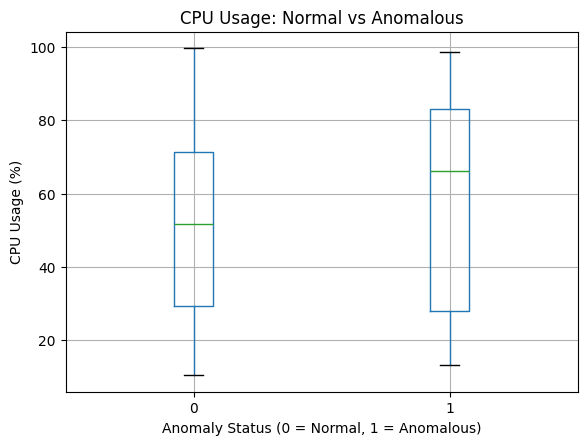

In [17]:
import matplotlib.pyplot as plt

df.boxplot(column="cpu_usage_percent", by="is_anomaly")

plt.title("CPU Usage: Normal vs Anomalous")
plt.suptitle("")
plt.xlabel("Anomaly Status (0 = Normal, 1 = Anomalous)")
plt.ylabel("CPU Usage (%)")
plt.show()

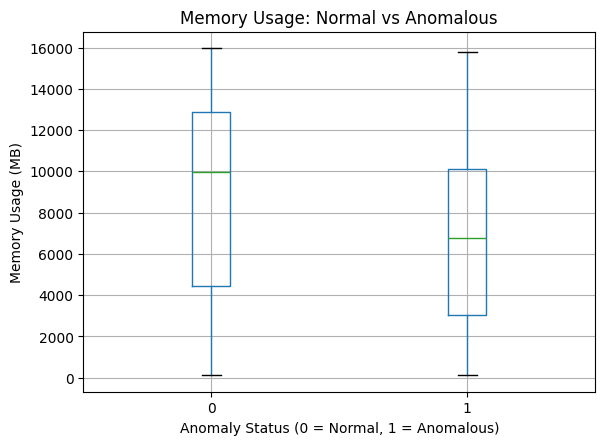

In [18]:
df.boxplot(column="memory_usage_mb", by="is_anomaly")

plt.title("Memory Usage: Normal vs Anomalous")
plt.suptitle("")
plt.xlabel("Anomaly Status (0 = Normal, 1 = Anomalous)")
plt.ylabel("Memory Usage (MB)")
plt.show()

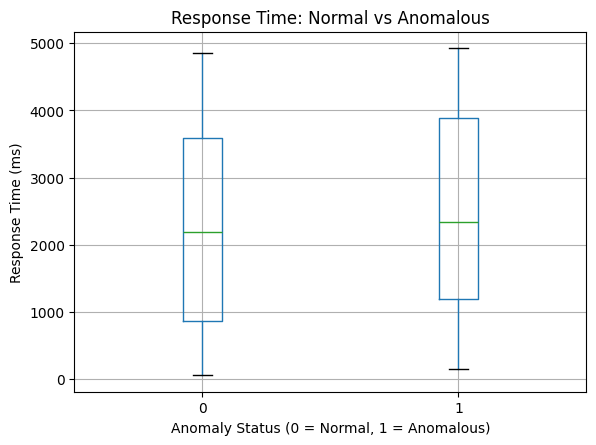

In [19]:
df.boxplot(column="response_time_ms", by="is_anomaly")

plt.title("Response Time: Normal vs Anomalous")
plt.suptitle("")
plt.xlabel("Anomaly Status (0 = Normal, 1 = Anomalous)")
plt.ylabel("Response Time (ms)")
plt.show()

In [20]:
df.groupby("is_anomaly")[
    ["response_time_ms", "cpu_usage_percent", "memory_usage_mb"]
].mean()

,response_time_ms,cpu_usage_percent,memory_usage_mb
is_anomaly,,,
0,2295.327481,51.486641,8823.542748
1,2476.272174,58.165652,6695.682174


In [21]:
df.groupby("is_anomaly")[
    ["response_time_ms", "cpu_usage_percent", "memory_usage_mb"]
].median()

,response_time_ms,cpu_usage_percent,memory_usage_mb
is_anomaly,,,
0,2183.33,51.66,9949.89
1,2336.22,66.06,6782.39


In [22]:
df[
    ["response_time_ms", "cpu_usage_percent", "memory_usage_mb"]
].corr()

,response_time_ms,cpu_usage_percent,memory_usage_mb
response_time_ms,1.000000,-0.048480,0.006529
cpu_usage_percent,-0.048480,1.000000,-0.064969
memory_usage_mb,0.006529,-0.064969,1.000000


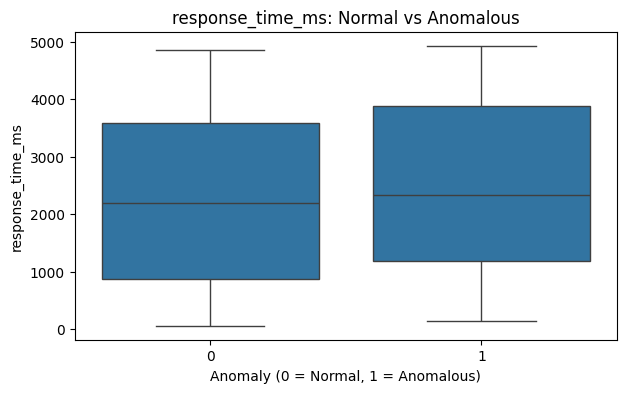

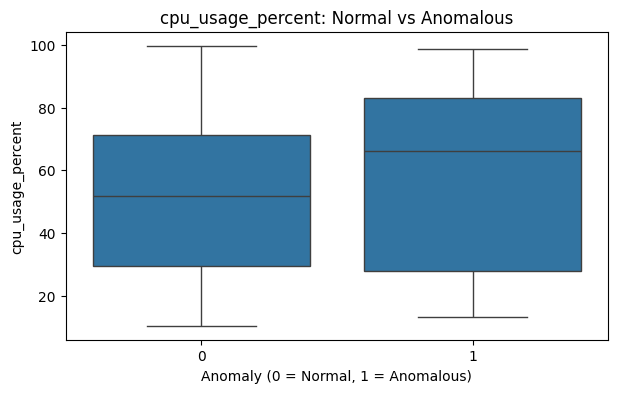

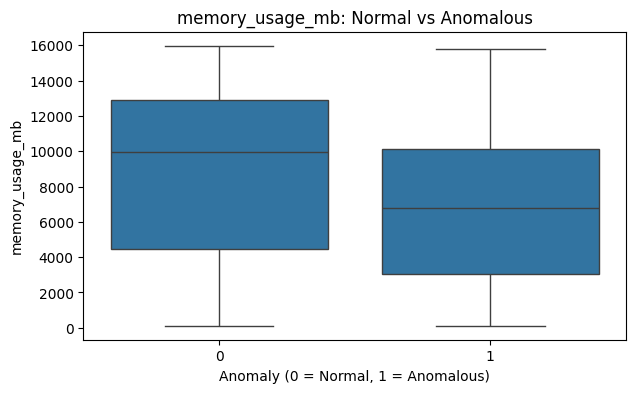

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "response_time_ms",
    "cpu_usage_percent",
    "memory_usage_mb"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="is_anomaly", y=feature, data=df)
    plt.title(f"{feature}: Normal vs Anomalous")
    plt.xlabel("Anomaly (0 = Normal, 1 = Anomalous)")
    plt.ylabel(feature)
    plt.show()
    

In [24]:
for feature in [
    "response_time_ms",
    "cpu_usage_percent",
    "memory_usage_mb"
]:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]

    print(f"\n{feature}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)}")


response_time_ms
Lower bound: -2943.18
Upper bound: 7689.64
Number of outliers: 0

cpu_usage_percent
Lower bound: -42.53
Upper bound: 148.07
Number of outliers: 0

memory_usage_mb
Lower bound: -8161.70
Upper bound: 24334.57
Number of outliers: 0


In [25]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df["timestamp"].min())
print(df["timestamp"].max())
print(df["timestamp"].dt.hour.value_counts().sort_index())

2025-01-01 00:00:00
2025-01-01 16:35:00
timestamp
0     12
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
15    12
16     8
Name: count, dtype: int64


In [26]:
features = [
    "response_time_ms",
    "cpu_usage_percent",
    "memory_usage_mb",
    "service_name",
    "log_level",
    "region"
]

X = df[features]
y = df["is_anomaly"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 6)
y shape: (200,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train: (160, 6)
X_test: (40, 6)
y_train: (160,)
y_test: (40,)

Training class distribution:
is_anomaly
0    105
1     55
Name: count, dtype: int64

Testing class distribution:
is_anomaly
0    26
1    14
Name: count, dtype: int64


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "response_time_ms",
    "cpu_usage_percent",
    "memory_usage_mb"
]

categorical_features = [
    "service_name",
    "log_level",
    "region"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (160, 15)
Testing shape: (40, 15)


In [29]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42)

model_lr.fit(X_train_processed, y_train)

y_pred_lr = model_lr.predict(X_test_processed)

print("Predictions:", y_pred_lr)

Predictions: [1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0
 0 1 0]


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.575
Precision: 0.3333333333333333
Recall: 0.21428571428571427
F1 Score: 0.2608695652173913

Confusion Matrix:
[[20  6]
 [11  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.77      0.70        26
           1       0.33      0.21      0.26        14

    accuracy                           0.57        40
   macro avg       0.49      0.49      0.48        40
weighted avg       0.54      0.57      0.55        40



In [31]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42
)

model_dt.fit(X_train_processed, y_train)

y_pred_dt = model_dt.predict(X_test_processed)

print("Predictions:", y_pred_dt)

Predictions: [1 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 0 0 0 1 0
 1 1 0]


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.525
Precision: 0.35294117647058826
Recall: 0.42857142857142855
F1 Score: 0.3870967741935484

Confusion Matrix:
[[15 11]
 [ 8  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.58      0.61        26
           1       0.35      0.43      0.39        14

    accuracy                           0.53        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.55      0.53      0.53        40



In [33]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train_processed, y_train)

y_pred_knn = model_knn.predict(X_test_processed)

print("Predictions:", y_pred_knn)

Predictions: [0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]


In [34]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1 Score:", f1_knn)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7
Precision: 0.6666666666666666
Recall: 0.2857142857142857
F1 Score: 0.4

Confusion Matrix:
[[24  2]
 [10  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.92      0.80        26
           1       0.67      0.29      0.40        14

    accuracy                           0.70        40
   macro avg       0.69      0.60      0.60        40
weighted avg       0.69      0.70      0.66        40



In [35]:
X_core = df[
    [
        "response_time_ms",
        "cpu_usage_percent",
        "memory_usage_mb"
    ]
]

X_train_core, X_test_core, y_train_core, y_test_core = train_test_split(
    X_core,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train_core.shape)
print("Testing:", X_test_core.shape)

Training: (160, 3)
Testing: (40, 3)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler_core = StandardScaler()

X_train_core_processed = scaler_core.fit_transform(X_train_core)
X_test_core_processed = scaler_core.transform(X_test_core)

print("Training shape:", X_train_core_processed.shape)
print("Testing shape:", X_test_core_processed.shape)

Training shape: (160, 3)
Testing shape: (40, 3)


In [37]:
model_lr_core = LogisticRegression(random_state=42)

model_lr_core.fit(X_train_core_processed, y_train_core)

y_pred_lr_core = model_lr_core.predict(X_test_core_processed)

print("Predictions:", y_pred_lr_core)

Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 1 0]


In [38]:
accuracy_lr_core = accuracy_score(y_test_core, y_pred_lr_core)
precision_lr_core = precision_score(y_test_core, y_pred_lr_core)
recall_lr_core = recall_score(y_test_core, y_pred_lr_core)
f1_lr_core = f1_score(y_test_core, y_pred_lr_core)

print("Accuracy:", accuracy_lr_core)
print("Precision:", precision_lr_core)
print("Recall:", recall_lr_core)
print("F1 Score:", f1_lr_core)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_core, y_pred_lr_core))

Accuracy: 0.625
Precision: 0.3333333333333333
Recall: 0.07142857142857142
F1 Score: 0.11764705882352941

Confusion Matrix:
[[24  2]
 [13  1]]


In [39]:
model_dt_core = DecisionTreeClassifier(random_state=42)

model_dt_core.fit(X_train_core_processed, y_train_core)

y_pred_dt_core = model_dt_core.predict(X_test_core_processed)

accuracy_dt_core = accuracy_score(y_test_core, y_pred_dt_core)
precision_dt_core = precision_score(y_test_core, y_pred_dt_core)
recall_dt_core = recall_score(y_test_core, y_pred_dt_core)
f1_dt_core = f1_score(y_test_core, y_pred_dt_core)

print("Accuracy:", accuracy_dt_core)
print("Precision:", precision_dt_core)
print("Recall:", recall_dt_core)
print("F1 Score:", f1_dt_core)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_core, y_pred_dt_core))

Accuracy: 0.65
Precision: 0.5
Recall: 0.42857142857142855
F1 Score: 0.46153846153846156

Confusion Matrix:
[[20  6]
 [ 8  6]]


In [40]:
model_knn_core = KNeighborsClassifier(n_neighbors=5)

model_knn_core.fit(X_train_core_processed, y_train_core)

y_pred_knn_core = model_knn_core.predict(X_test_core_processed)

accuracy_knn_core = accuracy_score(y_test_core, y_pred_knn_core)
precision_knn_core = precision_score(y_test_core, y_pred_knn_core)
recall_knn_core = recall_score(y_test_core, y_pred_knn_core)
f1_knn_core = f1_score(y_test_core, y_pred_knn_core)

print("Accuracy:", accuracy_knn_core)
print("Precision:", precision_knn_core)
print("Recall:", recall_knn_core)
print("F1 Score:", f1_knn_core)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_core, y_pred_knn_core))

Accuracy: 0.425
Precision: 0.09090909090909091
Recall: 0.07142857142857142
F1 Score: 0.08

Confusion Matrix:
[[16 10]
 [13  1]]


In [41]:
errors = X_test_core.copy()

errors["actual"] = y_test_core
errors["predicted"] = y_pred_dt_core

misclassified = errors[
    errors["actual"] != errors["predicted"]
]

print("Number of misclassified observations:", len(misclassified))
print(misclassified)

Number of misclassified observations: 14
     response_time_ms  cpu_usage_percent  memory_usage_mb  actual  predicted
1             1576.21              91.53          4372.13       0          1
74            2348.32              84.82          5062.22       1          0
12            1408.12              69.26         14429.53       1          0
198           4139.73              28.00          7873.77       1          0
125            147.28              23.50          4085.93       1          0
19            4308.58              19.78         12075.92       1          0
108           2331.79              83.45          3015.60       1          0
134           1818.07              66.87          6263.26       0          1
178            431.46              70.92          2466.67       1          0
33            1025.67              71.29          2579.16       0          1
103           1188.76              52.11           428.42       1          0
36            4280.90              

In [42]:
misclassified_with_type = misclassified.copy()

misclassified_with_type["anomaly_type"] = df.loc[
    misclassified_with_type.index,
    "anomaly_type"
]

print(misclassified_with_type)

     response_time_ms  cpu_usage_percent  memory_usage_mb  actual  predicted  \
1             1576.21              91.53          4372.13       0          1   
74            2348.32              84.82          5062.22       1          0   
12            1408.12              69.26         14429.53       1          0   
198           4139.73              28.00          7873.77       1          0   
125            147.28              23.50          4085.93       1          0   
19            4308.58              19.78         12075.92       1          0   
108           2331.79              83.45          3015.60       1          0   
134           1818.07              66.87          6263.26       0          1   
178            431.46              70.92          2466.67       1          0   
33            1025.67              71.29          2579.16       0          1   
103           1188.76              52.11           428.42       1          0   
36            4280.90              93.10

In [43]:
feature_importance = pd.Series(
    model_dt_core.feature_importances_,
    index=X_core.columns
)

print(feature_importance.sort_values(ascending=False))

cpu_usage_percent    0.438024
response_time_ms     0.318765
memory_usage_mb      0.243211
dtype: float64


In [44]:
y_prob_dt_core = model_dt_core.predict_proba(X_test_core_processed)[:, 1]

print(y_prob_dt_core)

[1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0.]


In [45]:
from sklearn.metrics import roc_auc_score

roc_auc_dt_core = roc_auc_score(
    y_test_core,
    y_prob_dt_core
)

print("ROC-AUC:", roc_auc_dt_core)

ROC-AUC: 0.5989010989010989


In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN"
    ],
    "Core Accuracy": [0.625, 0.650, 0.425],
    "Core Precision": [0.333, 0.500, 0.091],
    "Core Recall": [0.071, 0.429, 0.071],
    "Core F1": [0.118, 0.462, 0.080],
    "Context Accuracy": [0.575, 0.525, 0.700],
    "Context Precision": [0.333, 0.353, 0.667],
    "Context Recall": [0.214, 0.429, 0.286],
    "Context F1": [0.261, 0.387, 0.400]
})

print(comparison)

                 Model  Core Accuracy  Core Precision  Core Recall  Core F1  \
0  Logistic Regression          0.625           0.333        0.071    0.118   
1        Decision Tree          0.650           0.500        0.429    0.462   
2                  KNN          0.425           0.091        0.071    0.080   

   Context Accuracy  Context Precision  Context Recall  Context F1  
0             0.575              0.333           0.214       0.261  
1             0.525              0.353           0.429       0.387  
2             0.700              0.667           0.286       0.400  


In [47]:
model_dt_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

model_dt_balanced.fit(
    X_train_core_processed,
    y_train_core
)

y_pred_dt_balanced = model_dt_balanced.predict(
    X_test_core_processed
)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test_core, y_pred_dt_balanced))
print("Precision:", precision_score(y_test_core, y_pred_dt_balanced))
print("Recall:", recall_score(y_test_core, y_pred_dt_balanced))
print("F1 Score:", f1_score(y_test_core, y_pred_dt_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_core, y_pred_dt_balanced))

Accuracy: 0.575
Precision: 0.38461538461538464
Recall: 0.35714285714285715
F1 Score: 0.37037037037037035

Confusion Matrix:
[[18  8]
 [ 9  5]]


In [49]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

final_pipeline.fit(X_train_core, y_train_core)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [50]:
final_pred = final_pipeline.predict(X_test_core)

print("Accuracy:", accuracy_score(y_test_core, final_pred))
print("Precision:", precision_score(y_test_core, final_pred))
print("Recall:", recall_score(y_test_core, final_pred))
print("F1 Score:", f1_score(y_test_core, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_core, final_pred))

Accuracy: 0.65
Precision: 0.5
Recall: 0.42857142857142855
F1 Score: 0.46153846153846156

Confusion Matrix:
[[20  6]
 [ 8  6]]


In [51]:
import joblib

joblib.dump(final_pipeline, "final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [52]:
loaded_model = joblib.load("final_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [53]:
sample = [[80, 5000, 3000]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [54]:
sample = [[3000, 80, 5000]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
